# Pre-processing
## Lucy Gagnon

In [26]:
## step 1: load data
import os
import glob
files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
files

['/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019195000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019284000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019332000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_QC_250m_1_doy2019032000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_QC_250m_1_doy2019055000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019019000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019197000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019308000000_aid0001.tif',
 '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_QC_250m_1_doy2019341000000_aid0001.tif',
 '/shared_space

In [15]:
import rasterio

# Define the path to your TIFF file
tif_file_path = '/shared_space/Galveston_Bay/MODIS_250/MYD09GQ.061_QC_250m_1_doy2020022000000_aid0001.tif'

# Open the TIFF file in read mode ('r')
with rasterio.open(tif_file_path, 'r') as dataset:
    # You can now access various properties of the dataset
    print(f"Driver: {dataset.driver}")
    print(f"CRS: {dataset.crs}")
    print(f"Bounds: {dataset.bounds}")
    print(f"Width: {dataset.width}")
    print(f"Height: {dataset.height}")
    print(f"Number of bands: {dataset.count}")
    print(f"Band 1 data type: {dataset.dtypes[0]}")

    # To read the entire image (or a specific band) as a NumPy array:
    # For a single-band image:
    band1_data = dataset.read(1) 
    print(f"Shape of band 1 data: {band1_data.shape}")

    # For a multi-band image, you can read all bands at once or individual bands
    # all_bands_data = dataset.read() # Reads all bands into a 3D NumPy array
    # band2_data = dataset.read(2) # Reads the second band


Driver: GTiff
CRS: EPSG:4326
Bounds: BoundingBox(left=-96.00208332473296, bottom=28.49999999744682, right=-93.99999999157899, top=30.00208333064559)
Width: 961
Height: 721
Number of bands: 1
Band 1 data type: uint16
Shape of band 1 data: (721, 961)


In [16]:
#load MODIS 250m data
files = glob.glob("/shared_space/Galveston_Bay/MODIS_250/*")
all_data = []

for file in files:
    with rasterio.open(file, 'r') as dataset:
        data = dataset.read(1) 
        all_data.append(data)
        
        #read in datetime
        

In [22]:
print(all_data)

[array([[2995, 2995, 2995, ..., 2995, 2995, 2995],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       ...,
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096]], dtype=uint16), array([[2995, 2995, 2995, ..., 2995, 2995, 2995],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       ...,
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096]], dtype=uint16), array([[2995, 2995, 2995, ..., 2995, 2995, 2995],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       ...,
       [2995, 4096, 4096, ..., 7425, 7425, 7425],
       [2995, 4096, 4096, ..., 4096, 4096, 4096],
       [2995, 4096, 4096, ..., 4096, 7425, 7425]], dtype=uint16), array([[2995, 2

In [2]:
#load observed data
import pandas as pd
file = '/shared_space/Galveston_Bay/All_Observed_Data.csv'
fp = pd.read_csv(file)
#print(fp.head())
lat_obs = fp['lat']
lon_obs = fp['lon']

#print(datetime)
#what are units of DO??
#convert targets to UTC for now
fp['DateTime'] = pd.to_datetime(fp['DateTime'])

# If they are naive but represent local Houston wall time:
fp['datetime_local'] = fp['DateTime'].dt.tz_localize('America/Chicago', ambiguous='infer')  # attach tz
# Option A: convert sample times to UTC (recommended if ds.time is in UTC)
fp['datetime_utc'] = fp['datetime_local'].dt.tz_convert('UTC')
fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
fp['datetime_utc'] = fp['datetime_utc'].dt.tz_localize(None)
y = fp['Value'].values
print(fp.head())

             DateTime  Value        lat        lon  \
0 2010-01-04 00:00:00   12.0  29.295779 -94.918220   
1 2010-01-04 00:00:00   10.2  29.503736 -95.098957   
2 2010-01-05 09:02:00    9.7  29.723127 -94.942790   
3 2010-01-05 12:35:00   10.5  29.793630 -95.060914   
4 2010-01-07 00:00:00   10.5  29.591217 -95.042331   

                         source            datetime_local        datetime_utc  
0                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
1                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
2  Regional Monitoring Database 2010-01-05 09:02:00-06:00 2010-01-05 15:02:00  
3  Regional Monitoring Database 2010-01-05 12:35:00-06:00 2010-01-05 18:35:00  
4                   Stream Team 2010-01-07 00:00:00-06:00 2010-01-07 06:00:00  


In [10]:
print(fp)

                DateTime  Value        lat        lon  \
0    2010-01-04 00:00:00  12.00  29.295779 -94.918220   
1    2010-01-04 00:00:00  10.20  29.503736 -95.098957   
2    2010-01-05 09:02:00   9.70  29.723127 -94.942790   
3    2010-01-05 12:35:00  10.50  29.793630 -95.060914   
4    2010-01-07 00:00:00  10.50  29.591217 -95.042331   
5    2010-01-13 09:50:00  11.10  29.723127 -94.942790   
6    2010-01-19 12:20:00   8.00  29.675556 -94.666110   
7    2010-01-19 12:20:00   7.70  29.675556 -94.666110   
8    2010-01-19 12:20:00   7.80  29.675556 -94.666110   
9    2010-01-19 12:37:00   8.70  29.683161 -94.622400   
10   2010-01-19 13:10:00   8.50  29.584167 -94.494450   
11   2010-01-19 13:10:00   8.60  29.584167 -94.494450   
12   2010-01-22 00:00:00  11.70  29.563698 -95.066042   
13   2010-01-26 00:00:00   8.00  29.456134 -95.053732   
14   2010-01-26 17:10:00   7.80  29.683161 -94.622400   
15   2010-01-29 00:00:00   8.50  29.565576 -95.054155   
16   2010-01-29 00:00:00   7.20

In [4]:
#load ERA data
import xarray as xr
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020.nc'
ds = xr.open_dataset(file)

#lat_era = ds['lat'].values
#lon_era = ds['lon'].values
#wind_speed = ds['wind_speed'].values
#sst = ds['sst'].values
ds

<xarray.Dataset>
Dimensions:     (latitude: 7, longitude: 9, valid_time: 17544)
Coordinates:
    number      int64 ...
  * latitude    (latitude) float64 30.0 29.75 29.5 29.25 29.0 28.75 28.5
  * longitude   (longitude) float64 -96.0 -95.75 -95.5 ... -94.5 -94.25 -94.0
  * valid_time  (valid_time) datetime64[ns] 2019-01-01 ... 2020-12-31T23:00:00
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
    wind_speed  (valid_time, latitude, longitude) float32 ...
    sst         (valid_time, latitude, longitude) float32 ...

The ERA5 dataset includes lat, lon, time coordinates for the following variables: u10 and v10, which describe the eastward and northward component of wind, respectively; wind_speed; and sst, which gives sea surface temperature. The coordinates lat, lon are $0.25^o \times 0.25 ^o$ resolution and we have hourly data for 2019-2020. We will ask **Grace** if she already calculates wind_speed from the 10m bands; it seems so. Latitude is decreasing, longitude is increasing (-180,180). The lat, lon are in separate arrays.

In [5]:
import numpy as np
#extract predictor variable data 
predictor_vars = list(ds.data_vars)
n_pred = len(predictor_vars)
def extract_at_site_and_time(da, sitetime, site_lat, site_lon):
    sel = da.sel({'latitude': site_lat, 'longitude': site_lon, 'valid_time': sitetime},
                     method='nearest')
    val = np.asarray(sel.values).squeeze() 
    return float(val)
      

# build X array of predictors
X = np.full((len(y), n_pred), np.nan, dtype=float)
#loop through taxa
for i in range(len(y)):
    #extract lat, lon
    s_lat = lat_obs[i]
    s_lon = lon_obs[i]
    s_time = fp['datetime_utc'][i]
    #loop through predictor variables
    for j, var in enumerate(predictor_vars):
        #extract predictor data at each grid cell
        X[i, j] = extract_at_site_and_time(ds[var], s_time, s_lat, s_lon)


# check
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3136, 4)
y shape: (3136,)


In [6]:
#KEEP only wind_speed and sst ( has lots of NaNs so be careful)
#X = np.delete(X, [0, 1], axis=1)
print(X)

[[-0.07531738  0.33735657  0.34566191         nan]
 [-0.08312988  0.94282532  0.94648302         nan]
 [-0.0645752   1.46040344  1.46183038         nan]
 ...
 [ 6.39054871  4.19277954  7.6432004          nan]
 [ 6.39054871  4.19277954  7.6432004          nan]
 [ 6.39054871  4.19277954  7.6432004          nan]]


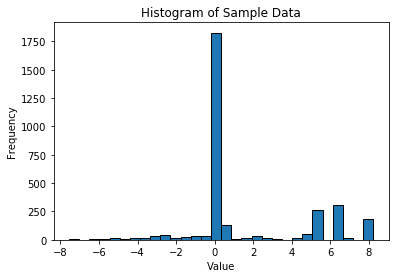

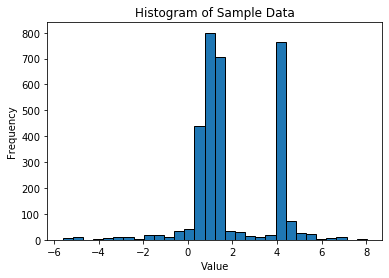

In [7]:
## step 4: outlier detection
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(X[:,0], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Sample Data")

# Display the plot
plt.show()


plt.hist(X[:,1], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Sample Data")

# Display the plot
plt.show()

In [8]:
## step 5: feature selection

In [9]:
feature_names = ['windspeed', 'sst']